In [ ]:
import os

import polars as pl

import llm_benchmark.utils.dataset as dataset
import llm_benchmark.utils.seshat_requests as seshat_requests
import llm_benchmark.config as config
import llm_benchmark.display.plotting as plotting

from llm_benchmark.utils.llm_interface.chatgpt import ChatGPTQuestionGenerationModule

from typing import Dict, List, Optional, Any, Tuple

module_dir: str = "/Users/apple/Documents/github/neurips_llms/llm-bechmark/db/seshat/modules"
main_dir: str = "/Users/apple/Documents/github/neurips_llms/llm-bechmark/db/seshat"

endpoint_identifiers: Dict[str, str] = seshat_requests.root_search_url(
    "https://seshat-db.com/api/", 
    use_cache=True, 
    cache_url="/Users/apple/Documents/github/neurips_llms/llm-bechmark/cache/seshat_root_url.pkl"
)

polity_mapping: Dict[str, str] = config.polity_mapping
openai_api_key: str = os.getenv("OPENAI_API_KEY")

question_instance: ChatGPTQuestionGenerationModule = ChatGPTQuestionGenerationModule(
    model_name="gpt-4",
    key=openai_api_key
)

ds: dataset.Dataset = dataset.Dataset(
    identifiers_endpoints=endpoint_identifiers,
    module_dir=module_dir,
    main_dir=main_dir,
    override=False,
    ignore_polities=["crisisdb/", "core/", "general/", "rt/"],
    polity_mapping=polity_mapping
)

#pl.Config.set_tbl_cols(100)
#print(ds.dataset_modules['sc/population-of-the-largest-settlements'].dataset.columns)
#question_instance.generate_questions(
#    ds.dataset_modules['sc/population-of-the-largest-settlements'], 
#    params=config.question_generation_params
#)

Initialized ChatGPTQuestionGenerationModule
Attempting dataset refresh. False
core/macro-regions https://seshat-db.com/api/core/macro-regions/
Ignoring polity core/macro-regions as per configuration.
core/regions https://seshat-db.com/api/core/regions/
Ignoring polity core/regions as per configuration.
core/ngas https://seshat-db.com/api/core/ngas/
Ignoring polity core/ngas as per configuration.
core/polities https://seshat-db.com/api/core/polities/
Ignoring polity core/polities as per configuration.
core/capitals https://seshat-db.com/api/core/capitals/
Ignoring polity core/capitals as per configuration.
core/nga-polity-relations https://seshat-db.com/api/core/nga-polity-relations/
Ignoring polity core/nga-polity-relations as per configuration.
core/sections https://seshat-db.com/api/core/sections/
Ignoring polity core/sections as per configuration.
core/subsections https://seshat-db.com/api/core/subsections/
Ignoring polity core/subsections as per configuration.
core/variable-hierarc

In [ ]:
endpoints: List[str] = ds.get_categorized_endpoints(dataset.DatasetType.WARFARE_FEATURES)
paired_counts: Dict[str, List[Tuple[str, int]]] = {}

for endpoint in endpoints:
    ds_module: dataset.WarfareFeaturesModule = ds.dataset_modules[endpoint]

    df_grouped = (
        ds_module.dataset
        .group_by("tag")
        .len()
        .sort("len", descending=True)
    )

    paired_counts[endpoint] = list(
        df_grouped.select(["tag", "len"]).iter_rows()
    )

plotting.plot_stacked_bar_chart(
    data=paired_counts,
    title="Distribution of Warfare Feature Tags",
    x_label="Warfare Feature Tags",
    y_label="Count",
    absolute=True,
    figsize=(50, 10),
    y_limits=(0, 500),
)

{'ec/luxury-fabrics': [('TRS', 105), ('IFR', 27), ('SSP', 22), ('UND', 2)], 'ec/luxury-manufactured-goods': [('TRS', 99), ('IFR', 25), ('SSP', 13), ('UND', 3)], 'ec/luxury-spices-incense-and-dyes': [('TRS', 75), ('IFR', 25), ('SSP', 17)], 'ec/luxury-drink-alcohol': [('TRS', 62), ('IFR', 37), ('SSP', 13), ('UND', 1)], 'ec/luxury-glass-goods': [('TRS', 64), ('IFR', 24), ('SSP', 11)], 'ec/luxury-fine-ceramic-wares': [('TRS', 65), ('IFR', 33), ('SSP', 11), ('UND', 1)], 'ec/luxury-statuary': [('TRS', 45), ('IFR', 31), ('SSP', 7)], 'ec/luxury-food': [('TRS', 62), ('IFR', 29), ('SSP', 11), ('UND', 1)], 'ec/other-luxury-personal-items': [('TRS', 2)]}
ec/luxury-fabrics 156
ec/luxury-manufactured-goods 140
ec/luxury-spices-incense-and-dyes 117
ec/luxury-drink-alcohol 113
ec/luxury-glass-goods 99
ec/luxury-fine-ceramic-wares 110
ec/luxury-statuary 83
ec/luxury-food 103
ec/other-luxury-personal-items 2


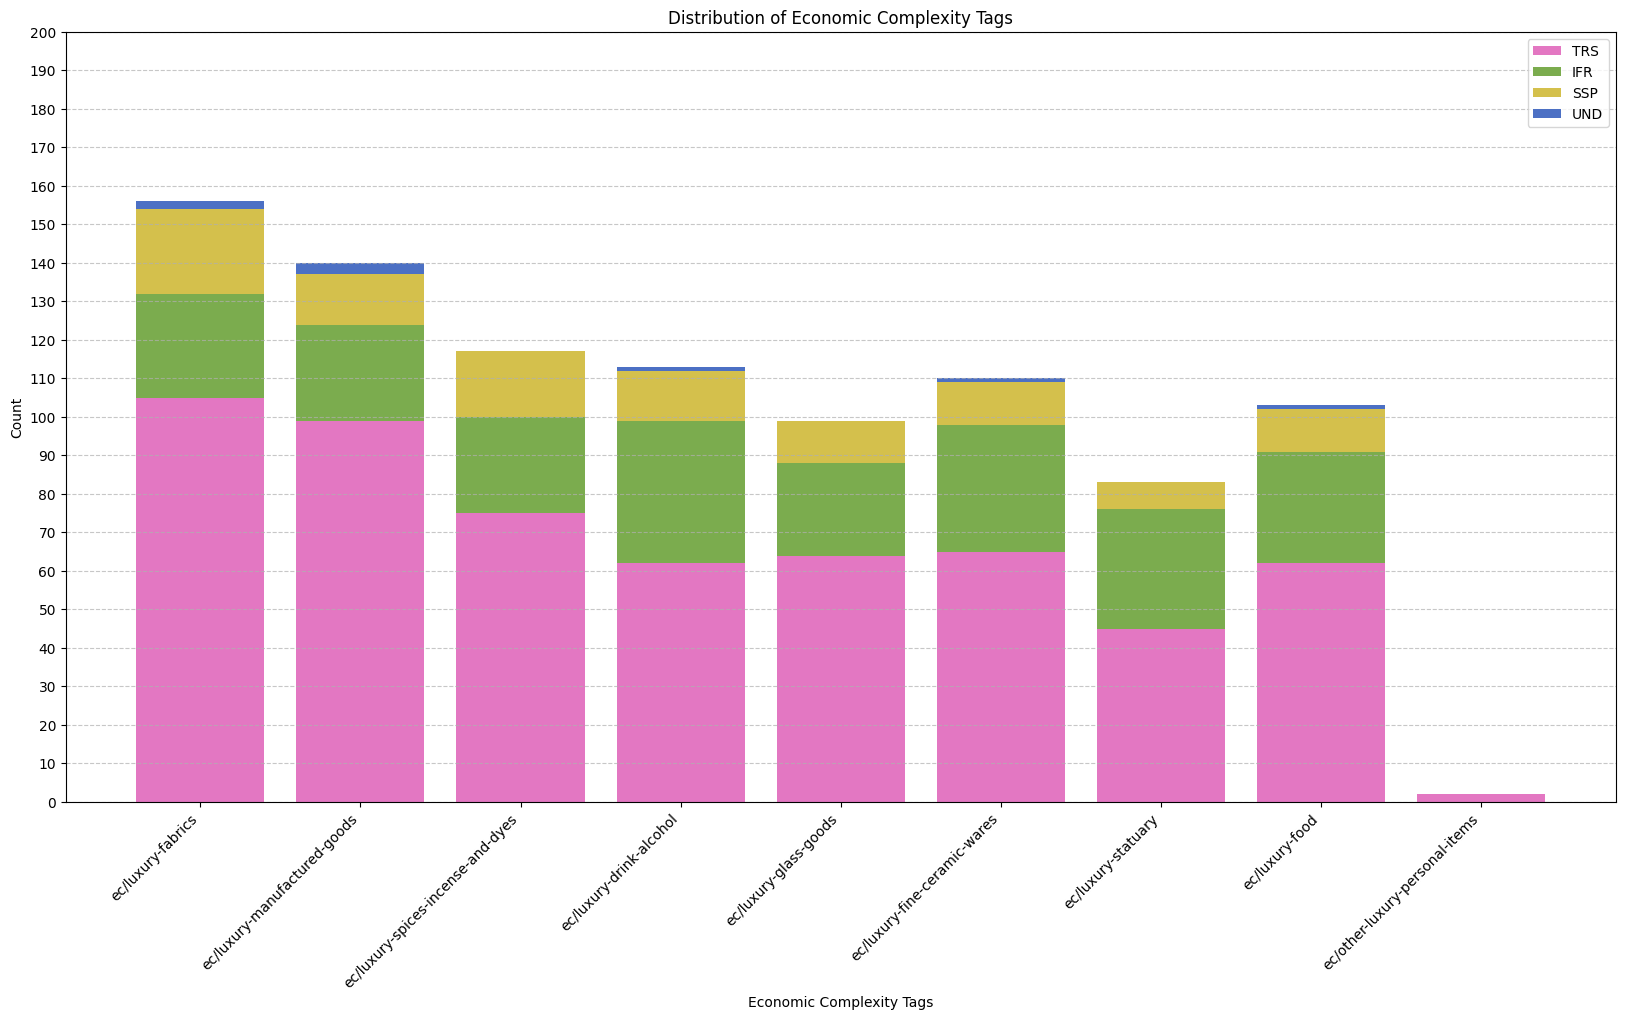

In [ ]:
endpoints: List[str] = ds.get_categorized_endpoints(dataset.DatasetType.ECONOMIC_COMPLEXITY)
paired_counts: Dict[str, List[Tuple[str, int]]] = {}

for endpoint in endpoints:
    ds_module: dataset.EconomicComplexityModule = ds.dataset_modules[endpoint]
    df_grouped = (
        ds_module.dataset
        .group_by("tag")
        .len()
        .sort("len", descending=True)
    )

    paired_counts[endpoint] = list(
        df_grouped.select(["tag", "len"]).iter_rows()
    )

plotting.plot_stacked_bar_chart(
    data=paired_counts,
    title="Distribution of Economic Complexity Tags",
    x_label="Economic Complexity Tags",
    y_label="Count",
    absolute=True,
    figsize=(20, 10),
    y_limits=(0, 200),
)

{'sc/polity-territories': [('TRS', 508), ('UND', 65), ('SSP', 33)], 'sc/polity-populations': [('TRS', 463), ('UND', 60), ('SSP', 53), ('IFR', 1)], 'sc/settlement-hierarchies': [('TRS', 538), ('UND', 21), ('SSP', 4)], 'sc/administrative-levels': [('TRS', 517), ('UND', 38), ('SSP', 15)], 'sc/religious-levels': [('TRS', 368), ('UND', 58), ('SSP', 20)], 'sc/military-levels': [('TRS', 379), ('UND', 46), ('SSP', 23)], 'sc/professional-military-officers': [('TRS', 252), ('IFR', 146), ('SSP', 58), ('UND', 17)], 'sc/professional-soldiers': [('TRS', 290), ('IFR', 144), ('SSP', 55), ('UND', 11)], 'sc/professional-priesthoods': [('TRS', 293), ('IFR', 115), ('SSP', 43), ('UND', 13)], 'sc/full-time-bureaucrats': [('TRS', 288), ('IFR', 147), ('SSP', 52), ('UND', 6)], 'sc/examination-systems': [('TRS', 145), ('IFR', 115), ('SSP', 110), ('UND', 15)], 'sc/merit-promotions': [('TRS', 144), ('IFR', 120), ('SSP', 103), ('UND', 31)], 'sc/specialized-government-buildings': [('TRS', 272), ('IFR', 142), ('SSP'

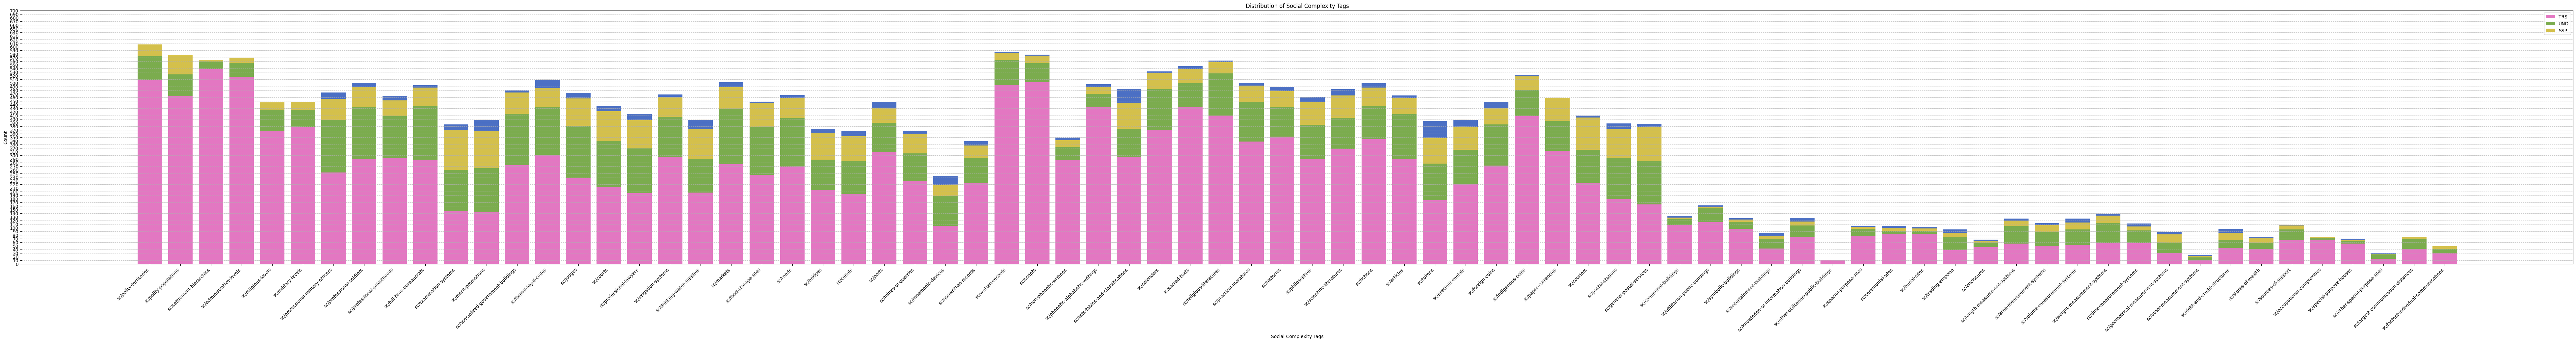

In [ ]:
endpoints: List[str] = ds.get_categorized_endpoints(dataset.DatasetType.SOCIAL_COMPLEXITY)
paired_counts: Dict[str, List[Tuple[str, int]]] = {}

for endpoint in endpoints:
    ds_module: dataset.SocialComplexityModule = ds.dataset_modules[endpoint]
    cols: List[str] = ds_module.dataset.columns
    if len(cols) == 0 or "tag" not in cols:
        continue

    df_grouped = (
        ds_module.dataset
        .group_by("tag")
        .len()
        .sort("len", descending=True)
    )

    paired_counts[endpoint] = list(
        df_grouped.select(["tag", "len"]).iter_rows()
    )
    
plotting.plot_stacked_bar_chart(
    data=paired_counts,
    title="Distribution of Social Complexity Tags",
    x_label="Social Complexity Tags",
    y_label="Count",
    absolute=True,
    figsize=(100, 10),
    y_limits=(0, 700),
)